# Put swing 2027 — 10, 30, 90 and 180 days

One contract, four sizes. The same swing over calendar 2027, exercisable on 10, 30, 90 or
180 days out of the year, priced side by side.

**How to use:** edit **§1 Curve** and **§2 Deal**, then Run All. Everything below is output.

The interesting question is how the price per MWh moves with the number of days. A 10-day
swing takes only the very cheapest days, so it buys well below the average forward; a 180-day
swing has to take half the year and converges towards it. That gap is the optionality you are
paying for.

Conventions — signs, units, what `delta` means — are in
[docs/MODEL-CONVENTIONS.md](docs/MODEL-CONVENTIONS.md); the traps are at the bottom.

In [1]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import storage_model as sm

pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (13, 3.4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)
print("ready")

ready


## 1. Curve

In [2]:
CURVE_SOURCE = "csv"                       # "csv" -> curve.csv  |  "quotes" -> ttf q.xlsx
AS_OF        = pd.Timestamp("2026-01-05")  # "quotes" only
VAL_DATE     = pd.Timestamp("2026-01-01")


def load_curve(source=CURVE_SOURCE, as_of=AS_OF, curve_start=VAL_DATE):
    if source == "csv":
        c = pd.read_csv("curve.csv")
        c["contractStart"] = pd.to_datetime(c["contractStart"], format="mixed")
        c["contractEnd"]   = pd.to_datetime(c["contractEnd"],   format="mixed")
        return c.sort_values("contractStart").reset_index(drop=True), "curve.csv"
    import re
    q = pd.read_excel("ttf q.xlsx")
    q = q.rename(columns={q.columns[0]: "quote_date"}).dropna(subset=["quote_date"])
    q["quote_date"] = pd.to_datetime(q["quote_date"], format="mixed")
    q = q.sort_values("quote_date").reset_index(drop=True)
    cols = sorted([c for c in q.columns if re.fullmatch(r"TTFc\d+", str(c))],
                  key=lambda c: int(re.search(r"\d+", str(c)).group()))
    row = sm.quote_row_for_fd_date(q, cols, as_of)
    return (sm.curve_df_for_storage(row, cols, curve_start=curve_start, include_da=True),
            f"ttf q.xlsx @ {pd.Timestamp(row['quote_date']):%Y-%m-%d}")


CURVE, CURVE_LABEL = load_curve()
print(f"{CURVE_LABEL}: {len(CURVE)} contracts, "
      f"{CURVE['contractStart'].min():%b-%y} .. {CURVE['contractEnd'].max():%b-%y}")

curve.csv: 38 contracts, Jan-26 .. Feb-29


## 2. Deal

`DAY_COUNTS` is the list of sizes to compare. Capacity follows from it:
`days x MWH_PER_DAY`.

`PRODUCT_TYPE` is `put_swing` — in this model that is the obligation to **buy** on the
cheapest days. Switch it to `call_swing` for the sell side (the right to sell on the dearest
days); everything below adapts, including the signs.

`DISCOUNT_RATE` is where time value goes: the annual rate at which cash released by the
deal can be redeployed, continuously compounded. It makes a euro on day *i* worth
`exp(-r·i/365.25)` today, so the optimiser stops treating every day as equally good.
**The two sides move in opposite directions** — a seller pulls exercise earlier to get the
cash, a buyer pushes it later to keep it. Leave it at `0.0` to switch time value off.

In [3]:
PRODUCT_TYPE  = "put_swing"                 # "put_swing" = buy | "call_swing" = sell
START, END    = "2027-01-01", "2027-12-31"
DAY_COUNTS    = [10, 30, 90, 180]
MWH_PER_DAY   = 1_000

VOL           = 0.50    # annualised
SMR           = 1.0     # mean reversion per year
DISCOUNT_RATE = 0.10    # annual, continuously compounded; 0.0 = no time value
N_P           = 30      # price-tree half-width; checked in section 6
CLIPS_PER_DAY = 1       # exercise is all-or-nothing on a day

WINDOW_DAYS = (pd.Timestamp(END) - pd.Timestamp(START)).days + 1
SIDE = "buy" if PRODUCT_TYPE == "put_swing" else "sell"
print(f"{PRODUCT_TYPE} ({SIDE}-side), {START} .. {END} = {WINDOW_DAYS} days, "
      f"discounted at {DISCOUNT_RATE:.0%}")
for d in DAY_COUNTS:
    print(f"   {d:4d} days = {d * MWH_PER_DAY:>8,} MWh   ({d / WINDOW_DAYS:5.1%} of the window)")

put_swing (buy-side), 2027-01-01 .. 2027-12-31 = 365 days, discounted at 10%
     10 days =   10,000 MWh   ( 2.7% of the window)
     30 days =   30,000 MWh   ( 8.2% of the window)
     90 days =   90,000 MWh   (24.7% of the window)
    180 days =  180,000 MWh   (49.3% of the window)


## 3. Run

Every deal is checked as it is priced:

- **volume** — gross MWh moved, against the capacity asked for
- **invariant** — the reported hedge must reprice the contract,

  `V0 = sum_i DF_i*delta_i*fwd_i - sum_i DF_i*(inj_cost_i*injected_i + wdr_cost_i*withdrawn_i)`

  The cost term matters whenever there is a strike or an injection cost: those are fixed cash
  amounts that do not scale with the price level. Without them the simpler
  `sum(DF*delta*fwd) == V0` only holds for a zero-cost deal.

In [4]:
def price(days, n_p=None, run_intrinsic=True, discount_rate=None):
    params = dict(product_type=PRODUCT_TYPE, valDate=VAL_DATE,
                  storageStart=START, storageEnd=END,
                  capacity_mwh=days * MWH_PER_DAY, daily_max=MWH_PER_DAY,
                  clips_per_day=CLIPS_PER_DAY, vol=VOL, sMR=SMR,
                  discount_rate=DISCOUNT_RATE if discount_rate is None else discount_rate,
                  n_p_full=N_P if n_p is None else n_p, run_intrinsic=run_intrinsic)
    t0 = time.perf_counter()
    s, r = sm.run_valuation(CURVE, params)
    secs = time.perf_counter() - t0

    n  = s.n_t
    dl = np.asarray(s.delta[:n]); df = s.d_curve[:n]
    v0 = float(s.v[0, s.n_p, s.initial_state])
    moved = s.prob[:n] * s.strat[:n] * s.v_step
    injected  = np.clip(moved, 0, None).sum(axis=(1, 2))
    withdrawn = -np.clip(moved, None, 0).sum(axis=(1, 2))
    cash = np.dot(df, np.asarray(s.i_cost)[:n] * injected
                      + np.asarray(s.w_cost)[:n] * withdrawn)
    gross = float(injected.sum() + withdrawn.sum())

    diag = dict(v0=v0, gross_mwh=gross, delta_mwh=float(dl.sum()),
                price_per_mwh=abs(v0) / gross if gross else np.nan,
                invariant=abs(float(np.dot(df * dl, s.fwd) - cash) - v0) / max(abs(v0), 1.0),
                starts=s.initial_state, n_states=s.n_states, secs=secs)
    return s, r, diag


RUNS = {}
for d in DAY_COUNTS:
    s, r, g = price(d)
    RUNS[d] = (s, r, g)
    print(f"  {d:4d} days   {g['secs']:5.1f}s   {g['gross_mwh']:>9,.0f} MWh "
          f"{SIDE}   {g['price_per_mwh']:7.3f} EUR/MWh   invariant {g['invariant']:.0e}")

    10 days     0.5s      10,000 MWh buy    19.964 EUR/MWh   invariant 7e-16


    30 days     0.2s      30,000 MWh buy    20.047 EUR/MWh   invariant 6e-16


    90 days     0.2s      90,000 MWh buy    20.312 EUR/MWh   invariant 5e-16


   180 days     0.3s     180,000 MWh buy    20.760 EUR/MWh   invariant 6e-16


## 4. Price against size

`price` is the average price actually paid (or received) per MWh. `flat` is the unweighted
average forward over the window — what you would get with no choice of days. The gap between
them is what the swing is worth.

,MWh,% of window,buy price EUR/MWh,flat EUR/MWh,vs flat,intrinsic,extrinsic,total,value EUR,delta MWh,invariant
days,,,,,,,,,,,
10,"10,000",2.7%,19.964,22.501,+2.537,1.408,1.129,2.537,"-199,638","-9,213",7e-16
30,"30,000",8.2%,20.047,22.501,+2.454,1.390,1.064,2.454,"-601,408","-27,784",6e-16
90,"90,000",24.7%,20.312,22.501,+2.189,1.333,0.856,2.189,"-1,828,086","-84,535",5e-16
180,"180,000",49.3%,20.760,22.501,+1.741,1.185,0.556,1.741,"-3,736,783","-172,670",6e-16


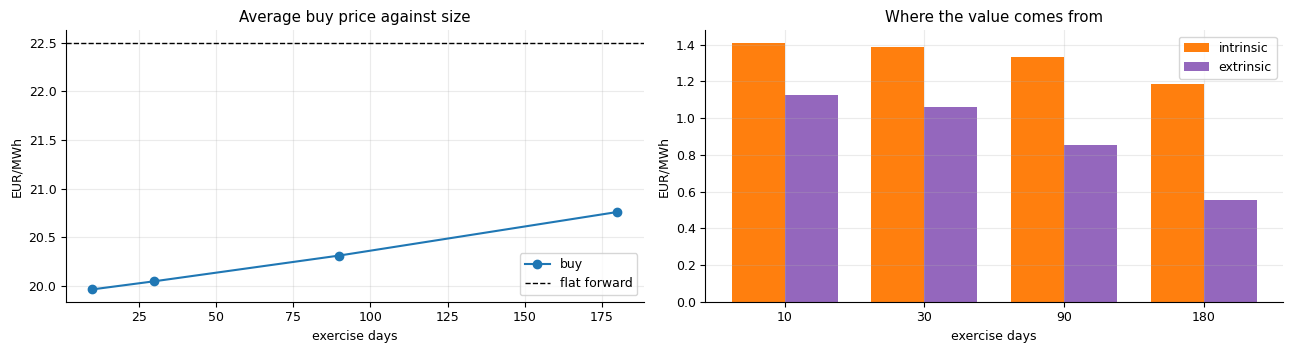

invariant worst case 7.3e-16
inventory: starts at 0 clips of 10 — a put swing starts empty and must fill; a call swing starts full and must empty.


In [5]:
rows = []
for d, (s, r, g) in RUNS.items():
    flat = r["flat_metric"]
    rows.append({
        "days": d,
        "MWh": g["gross_mwh"],
        "% of window": d / WINDOW_DAYS,
        f"{SIDE} price EUR/MWh": g["price_per_mwh"],
        "flat EUR/MWh": flat,
        "vs flat": (flat - g["price_per_mwh"]) if SIDE == "buy" else (g["price_per_mwh"] - flat),
        "intrinsic": r["intrinsic"],
        "extrinsic": r["extrinsic"],
        "total": r["total"],
        "value EUR": g["v0"],
        "delta MWh": g["delta_mwh"],
        "invariant": g["invariant"],
    })
summary = pd.DataFrame(rows).set_index("days")
display(summary.style.format({
        "MWh": "{:,.0f}", "% of window": "{:.1%}", f"{SIDE} price EUR/MWh": "{:.3f}",
        "flat EUR/MWh": "{:.3f}", "vs flat": "{:+.3f}", "intrinsic": "{:.3f}",
        "extrinsic": "{:.3f}", "total": "{:.3f}", "value EUR": "{:,.0f}",
        "delta MWh": "{:,.0f}", "invariant": "{:.0e}"})
    .set_caption(f"{PRODUCT_TYPE} {START}..{END}, {MWH_PER_DAY:,} MWh/day, "
                 f"vol {VOL:.0%}, n_p {N_P} — valued {VAL_DATE:%Y-%m-%d} off {CURVE_LABEL}"))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(summary.index, summary[f"{SIDE} price EUR/MWh"], "o-", color="tab:blue", label=SIDE)
ax[0].axhline(summary["flat EUR/MWh"].iloc[0], color="black", ls="--", lw=1, label="flat forward")
ax[0].set_xlabel("exercise days"); ax[0].set_ylabel("EUR/MWh")
ax[0].set_title(f"Average {SIDE} price against size"); ax[0].legend()

w = 0.38
ax[1].bar(np.arange(len(summary)) - w/2, summary["intrinsic"], w, label="intrinsic", color="tab:orange")
ax[1].bar(np.arange(len(summary)) + w/2, summary["extrinsic"], w, label="extrinsic", color="tab:purple")
ax[1].set_xticks(np.arange(len(summary))); ax[1].set_xticklabels(summary.index)
ax[1].set_xlabel("exercise days"); ax[1].set_ylabel("EUR/MWh")
ax[1].set_title("Where the value comes from"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"invariant worst case {summary['invariant'].max():.1e}")
print(f"inventory: starts at {RUNS[DAY_COUNTS[0]][2]['starts']} clips of "
      f"{RUNS[DAY_COUNTS[0]][2]['n_states']} — a put swing starts empty and must fill; a call "
      f"swing starts full and must empty.")

## 5. When does each size exercise?

Expected MWh per day. The small deal waits for the cheapest days and does nothing else; the
large one has to take most of the year and starts running out of choice.

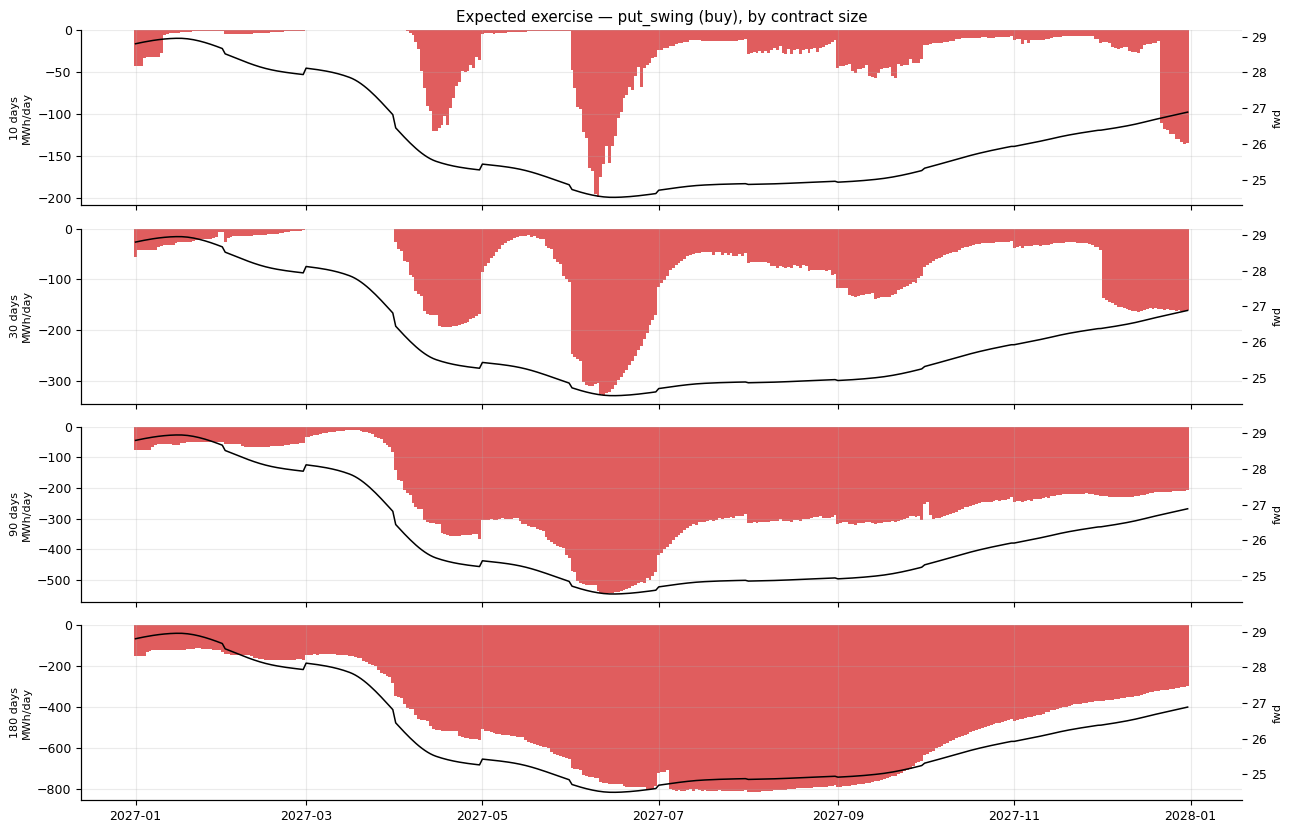

In [6]:
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 2.1 * len(RUNS)), sharex=True)
for ax, (d, (s, r, g)) in zip(np.atleast_1d(axes), RUNS.items()):
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    win = slice(s.Dt, s._active)
    ex = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win]
    px = pd.Series(s.fwd, index=idx).iloc[win]
    ax.bar(ex.index, ex.values, width=1.0,
           color="tab:red" if SIDE == "buy" else "tab:green", alpha=.75)
    ax.set_ylabel(f"{d} days\nMWh/day", fontsize=8)
    twin = ax.twinx(); twin.plot(px.index, px.values, color="black", lw=1.1)
    twin.set_ylabel("fwd", fontsize=8); twin.grid(False)
axes[0].set_title(f"Expected exercise — {PRODUCT_TYPE} ({SIDE}), by contract size")
plt.tight_layout(); plt.show()

## 6b. What the discount rate does

The deal repriced across rates, holding everything else fixed. `mean day` is the
volume-weighted exercise day within the window, so it shows the schedule moving, not just
the value. A buyer defers to keep the cash; a seller accelerates to get it.


In [7]:
rows = []
for rate in (0.0, 0.05, DISCOUNT_RATE, 0.20):
    s, r, g = price(30, discount_rate=rate)
    ex = np.abs(np.asarray(s.exp_ex[:s.n_t]))
    rows.append({"rate": rate,
                 f"{SIDE} price EUR/MWh": g["price_per_mwh"],
                 "flat EUR/MWh": r["flat_metric"],
                 "intrinsic": r["intrinsic"], "extrinsic": r["extrinsic"],
                 "value EUR": g["v0"],
                 "mean day": float(np.dot(np.arange(s.n_t), ex) / ex.sum()) - s.Dt})
rates = pd.DataFrame(rows).set_index("rate")
display(rates.style.format({f"{SIDE} price EUR/MWh": "{:.3f}", "flat EUR/MWh": "{:.3f}",
                            "intrinsic": "{:.3f}", "extrinsic": "{:.3f}",
                            "value EUR": "{:,.0f}", "mean day": "{:.0f}"})
        .format_index("{:.0%}")
        .set_caption(f"30-day deal repriced by discount rate — day 0 is {START}"))
print("`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:")
print("it measures choosing days, not the discounting itself.")


,buy price EUR/MWh,flat EUR/MWh,intrinsic,extrinsic,value EUR,mean day
rate,,,,,,
0%,23.524,26.104,1.542,1.037,"-705,727",178
5%,21.737,24.233,1.400,1.096,"-652,111",192
10%,20.047,22.501,1.390,1.064,"-601,408",206
20%,16.956,19.412,1.602,0.854,"-508,670",234


`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:
it measures choosing days, not the discounting itself.


## 6. Monthly hedge

MWh to trade in each month, per size. Negative is a buy.

Two columns per deal, because there are two hedge instruments. **forward** is the physical
volume, right against an OTC forward that settles with the deal — the discount factor
cancels. **futures** is that tailed by the discount factor, right against margined futures
whose variation margin moves today, and the correct number for PV risk. At a 10 % rate the
December column is about 18 % smaller once tailed; with no rate the two are identical.

Either way these are **local** ratios: correct derivatives, but strongly convex, so re-hedge
rather than holding them across a large move.

In [8]:
hedge = {}
for d, (s, r, g) in RUNS.items():
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    win = slice(s.Dt, s._active)
    hedge[f"{d}d forward"] = pd.Series(np.asarray(s.delta[:s.n_t]), index=idx).iloc[win].resample("MS").sum()
    hedge[f"{d}d futures"] = pd.Series(np.asarray(s.delta_pv[:s.n_t]), index=idx).iloc[win].resample("MS").sum()
hedge = pd.DataFrame(hedge).round(0)
hedge.index = hedge.index.strftime("%b-%y")
hedge.loc["TOTAL"] = hedge.sum()
display(hedge.style.format("{:,.0f}").set_caption("Monthly hedge, MWh of forward"))

,10d forward,10d futures,30d forward,30d futures,90d forward,90d futures,180d forward,180d futures
Jan-27,-179,-162,-417,-377,-874,-788,"-2,131","-1,921"
Feb-27,-36,-32,-150,-134,-836,-747,"-2,566","-2,294"
Mar-27,-0,-0,-2,-2,-398,-352,"-3,127","-2,771"
Apr-27,-994,-873,"-2,704","-2,376","-5,930","-5,212","-10,585","-9,305"
May-27,-35,-30,-855,-745,"-7,301","-6,365","-13,557","-11,819"
Jun-27,"-2,410","-2,085","-6,548","-5,664","-12,443","-10,761","-19,506","-16,867"
Jul-27,-383,-329,"-1,597","-1,371","-8,589","-7,368","-24,023","-20,600"
Aug-27,-645,-548,"-2,121","-1,804","-8,787","-7,472","-25,473","-21,661"
Sep-27,"-1,383","-1,166","-3,806","-3,210","-9,731","-8,206","-23,909","-20,164"
Oct-27,-363,-304,"-1,354","-1,133","-10,337","-8,645","-18,983","-15,879"


## 7. Is the tree wide enough?

`n_p` is the price-tree half-width. Too narrow and optionality is silently lost. The 10-day
deal is the most option-like, so it is the most demanding; if it is flat by the `N_P` you
chose, the rest are too.

In [9]:
conv = []
for n_p in (5, 10, 15, 20, 30, 45):
    s, r, g = price(min(DAY_COUNTS), n_p=n_p, run_intrinsic=False)
    conv.append({"n_p": n_p, "EUR/MWh": g["price_per_mwh"], "secs": g["secs"]})
conv = pd.DataFrame(conv).set_index("n_p")
conv["vs n_p=45"] = conv["EUR/MWh"] - conv.loc[45, "EUR/MWh"]
display(conv.style.format({"EUR/MWh": "{:.4f}", "vs n_p=45": "{:+.4f}", "secs": "{:.1f}"})
        .set_caption(f"Tree-width convergence — {min(DAY_COUNTS)}-day deal"))

,EUR/MWh,secs,vs n_p=45
n_p,,,
5,20.5469,0.1,+0.5830
10,20.0885,0.1,+0.1247
15,19.9787,0.1,+0.0148
20,19.9635,0.1,-0.0004
30,19.9638,0.1,-0.0000
45,19.9638,0.1,+0.0000


## Traps worth knowing

- **`delta` is not volume.** It is the forward MWh to trade — volume weighted by
  `E[S|exercise]/F` — so it exceeds volume when exercise happens at high prices and falls
  short when it happens at low ones. For a per-MWh price divide value by exercised volume,
  never by `delta`.
- **A put swing must buy.** It is an obligation, not a right: the quota is met on every path,
  which is why the small sizes look so good and the large ones do not. The right-not-obligation
  version is `call_swing` with `zero_penalty=True`.
- **The repricing identity carries a cost term** whenever there is a strike or an injection
  cost — see section 3.
- **The intrinsic split used to break with a strike** — `intrinsic = profiled - flat`
  compared a strike-net value with a raw forward average, so it moved by `K`: down for a
  call, up for a put. Fixed 2026-09-08; `flat_metric` is now reported net of the strike.
- **`exp_ex` is net per day**, which only matters for two-sided deals (storage).
- **The curve must reach one month past the deal** — the model carries a terminal condition
  past the last exercise day.
- **`sVol` and `sMR` are annualised** and their defaults are not calibrated to anything; see
  the calibration note in `docs/MODEL-CONVENTIONS.md`.